In [1]:
# Cell 0 — setup



In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

ROOT = Path("..").resolve()
df = pd.read_csv(ROOT / "data" / "processed" / "merged_with_features.csv")

# safety: typo + target type (in case this file was saved before the fix)
df["loan_purpose"] = df["loan_purpose"].replace({"Personaal": "Personal"})
df["default"] = df["default"].astype(int)

print(df.shape)
print(df["default"].mean())

(50000, 36)
0.08594


Cell 1 — target pie / bar (class imbalance)

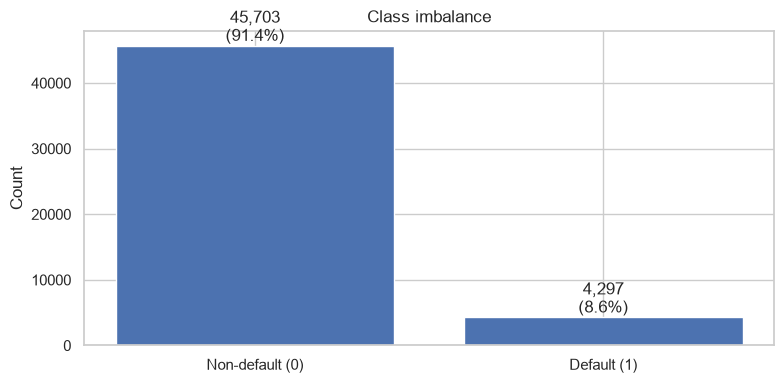

In [3]:
fig, ax = plt.subplots()
counts = df["default"].value_counts().sort_index()
ax.bar(["Non-default (0)", "Default (1)"], counts.values)
ax.set_title("Class imbalance")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom")
plt.tight_layout()
plt.show()

Cell 2 — default rate by category (4 small bar charts)

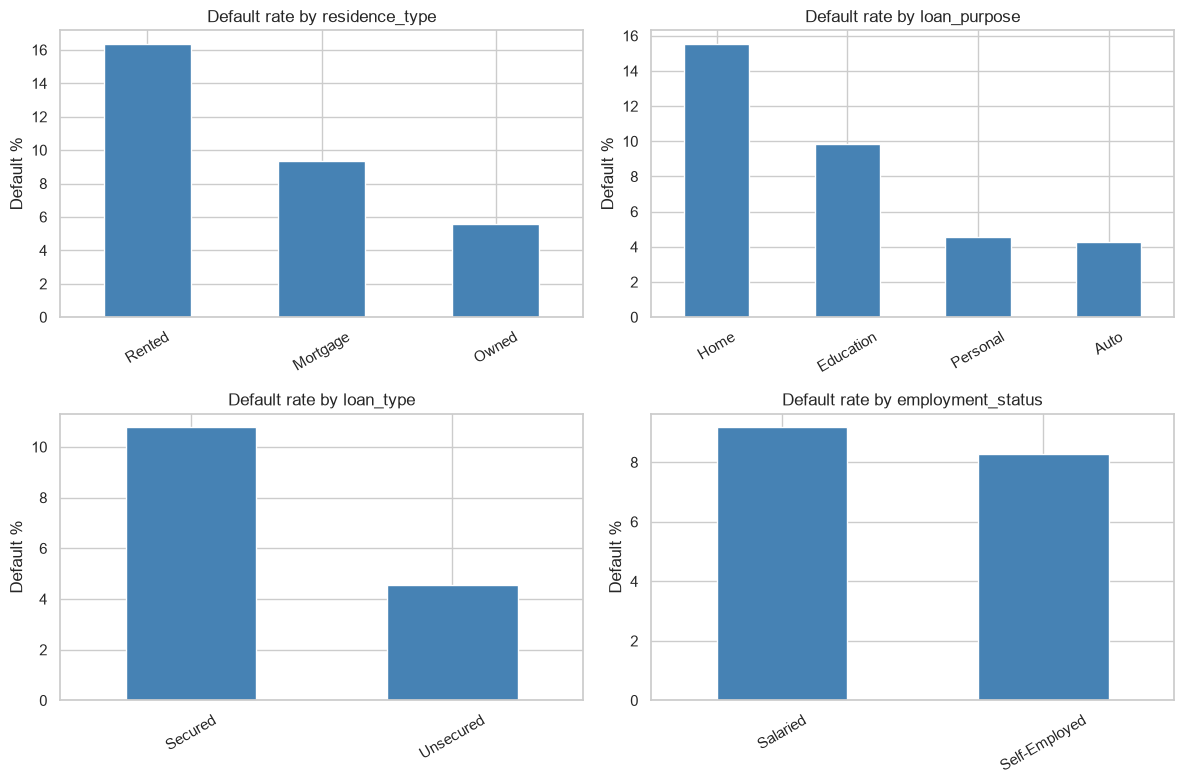

In [4]:
cats = ["residence_type", "loan_purpose", "loan_type", "employment_status"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, cats):
    rates = df.groupby(col)["default"].mean().mul(100).sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("Default %")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Cell 3 — the money plots (risk features vs default)

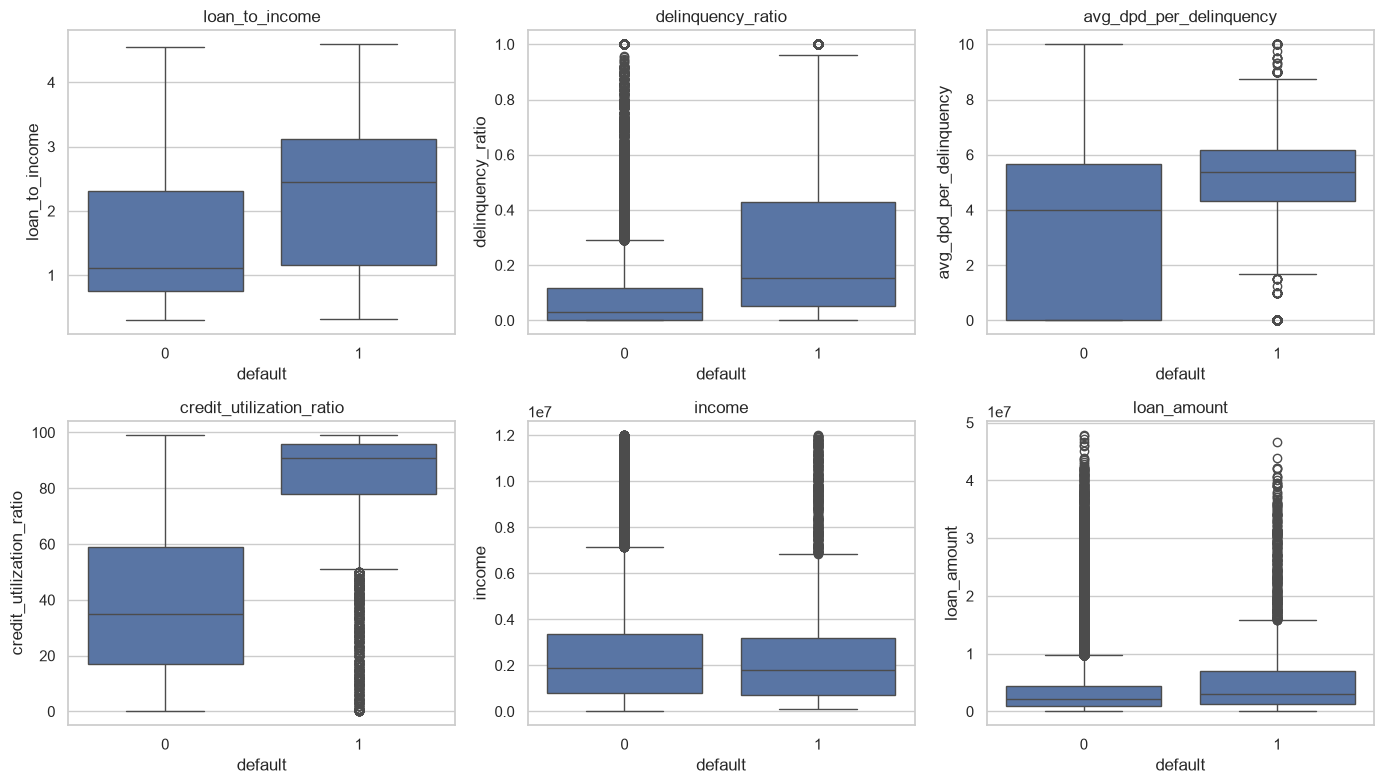

In [5]:
num_feats = [
    "loan_to_income",
    "delinquency_ratio",
    "avg_dpd_per_delinquency",
    "credit_utilization_ratio",
    "income",
    "loan_amount",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, num_feats):
    sns.boxplot(data=df, x="default", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("default")

plt.tight_layout()
plt.show()

Cell 4 — histograms of the 3 engineered features

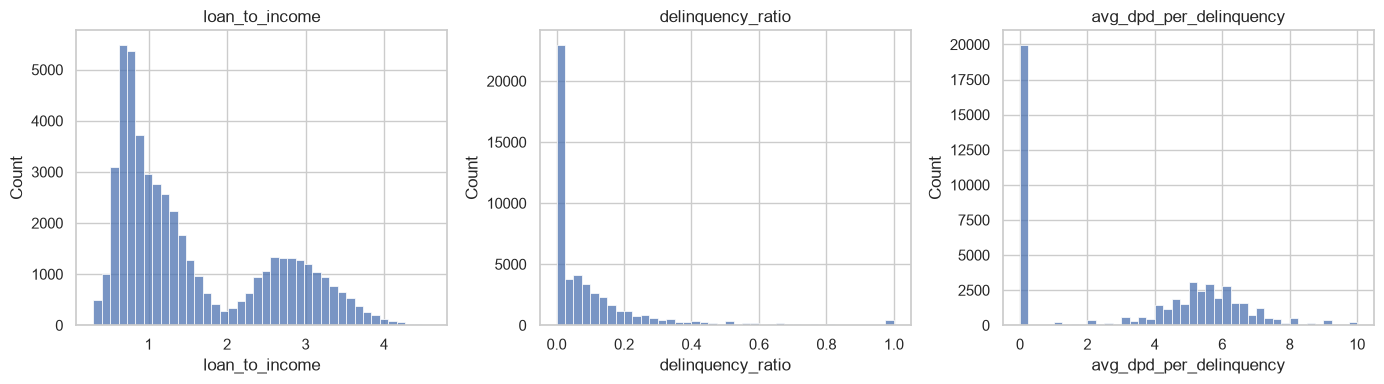

       loan_to_income  delinquency_ratio  avg_dpd_per_delinquency
count    49992.000000       50000.000000             50000.000000
mean         1.555239           0.103984                 3.297653
std          0.971679           0.172995                 2.904303
min          0.296170           0.000000                 0.000000
25%          0.770145           0.000000                 0.000000
50%          1.159964           0.037975                 4.333333
75%          2.453737           0.130435                 5.750000
max          4.591270           1.000000                10.000000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["loan_to_income", "delinquency_ratio", "avg_dpd_per_delinquency"]):
    sns.histplot(df[col], bins=40, ax=ax, kde=False)
    ax.set_title(col)

plt.tight_layout()
plt.show()

print(df[["loan_to_income", "delinquency_ratio", "avg_dpd_per_delinquency"]].describe())

Cell 5 — correlation heatmap (numeric only)

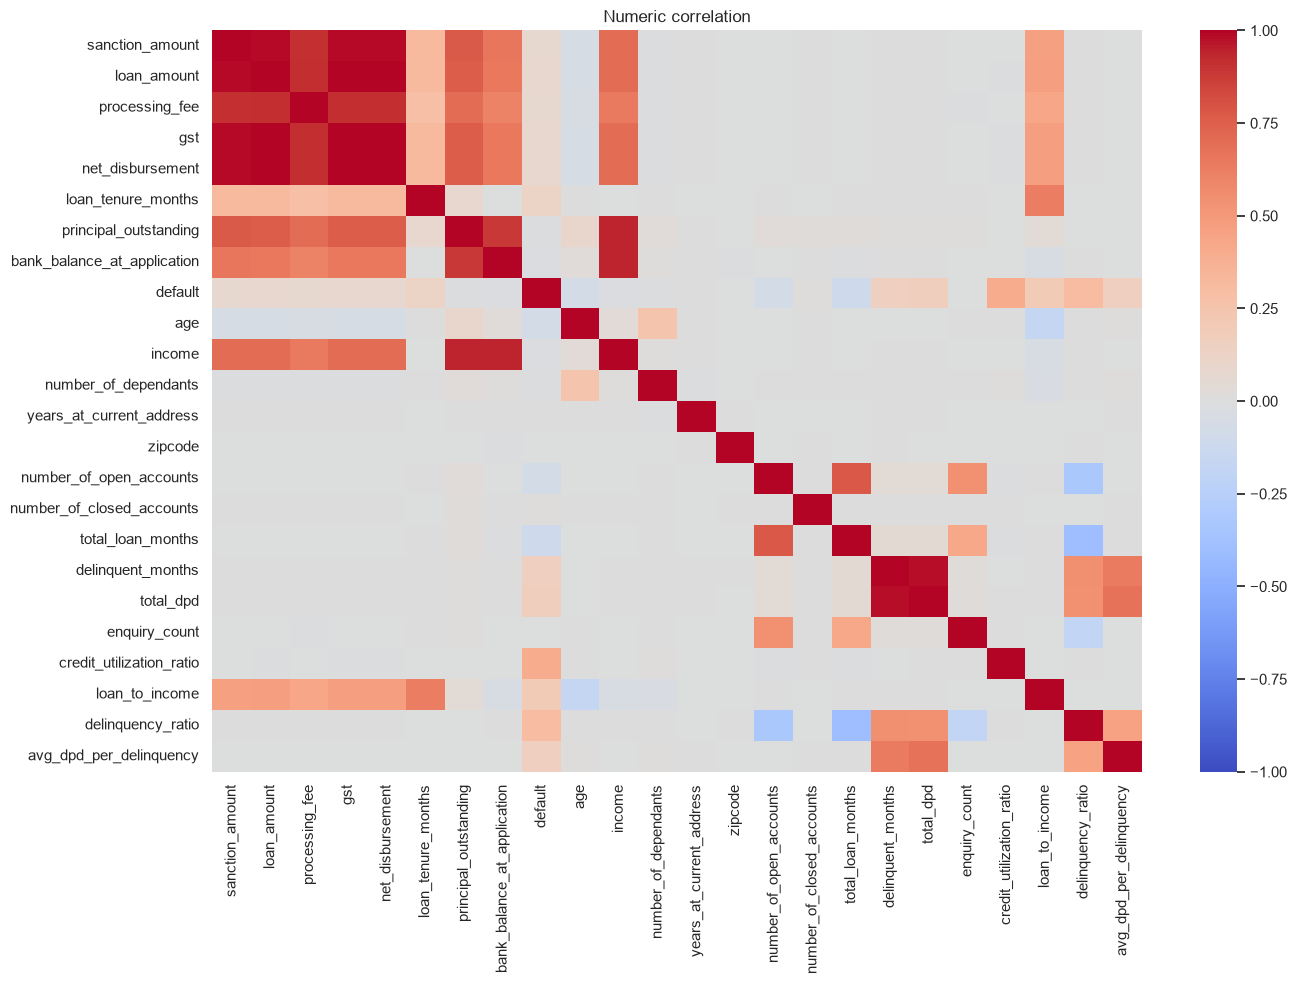

credit_utilization_ratio    0.401372
delinquency_ratio           0.311032
loan_to_income              0.202793
total_dpd                   0.166290
delinquent_months           0.163670
avg_dpd_per_delinquency     0.158877
loan_tenure_months          0.121673
total_loan_months          -0.101960
net_disbursement            0.084077
gst                         0.084077
loan_amount                 0.084077
sanction_amount             0.077263
Name: default, dtype: float64


In [8]:
num_cols = df.select_dtypes(include="number").columns.tolist()
# default is numeric now, keep it
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Numeric correlation")
plt.tight_layout()
plt.show()

print(
    corr["default"]
    .drop("default")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(12)
)

Cell 6 — save charts into reports (optional)


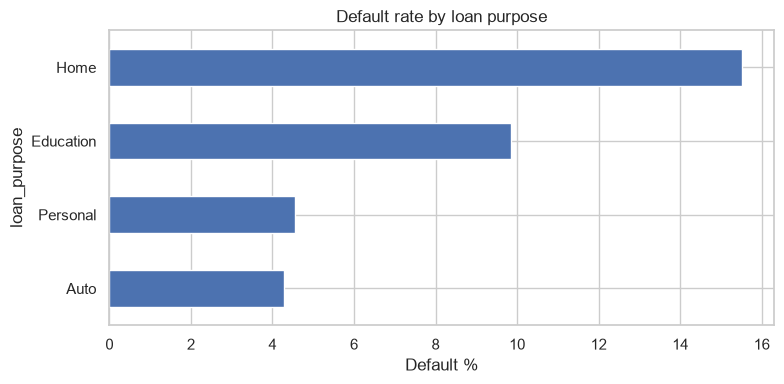

saved D:\Downloads\namaste_ankit_sql\ml_project_2\reports\default_by_purpose.png


In [9]:
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

fig = plt.figure()
df.groupby("loan_purpose")["default"].mean().mul(100).sort_values().plot(kind="barh")
plt.xlabel("Default %")
plt.title("Default rate by loan purpose")
plt.tight_layout()
fig.savefig(REPORTS / "default_by_purpose.png", dpi=120)
plt.show()
print("saved", REPORTS / "default_by_purpose.png")